In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import networkx as nx

In [2]:
df = pd.read_csv('master_dataset_clean.csv')
# Creazione della colonna date e pulizia percentuali
df['date'] = pd.to_datetime(df['month_id'], format='%Y%m')

for col in df.columns:
    if col not in ['country_name', 'month_id', 'date']:
        try:
            df[col] = df[col].astype(str).str.replace('%', '').astype(float)
        except ValueError:
            pass

### 1. Analisi del Trend Storico (2018-2025)
Mettere tutte le nazioni europee insieme avrebbe reso il grafico un caos illeggibile. Ho isolato le prime 5 potenze (G5) per confrontare l'andamento dei grammi di CO2 per kWh prodotto (`co2_g_kwh`). L'obiettivo è capire chi sta decarbonizzando davvero e chi invece è bloccato.

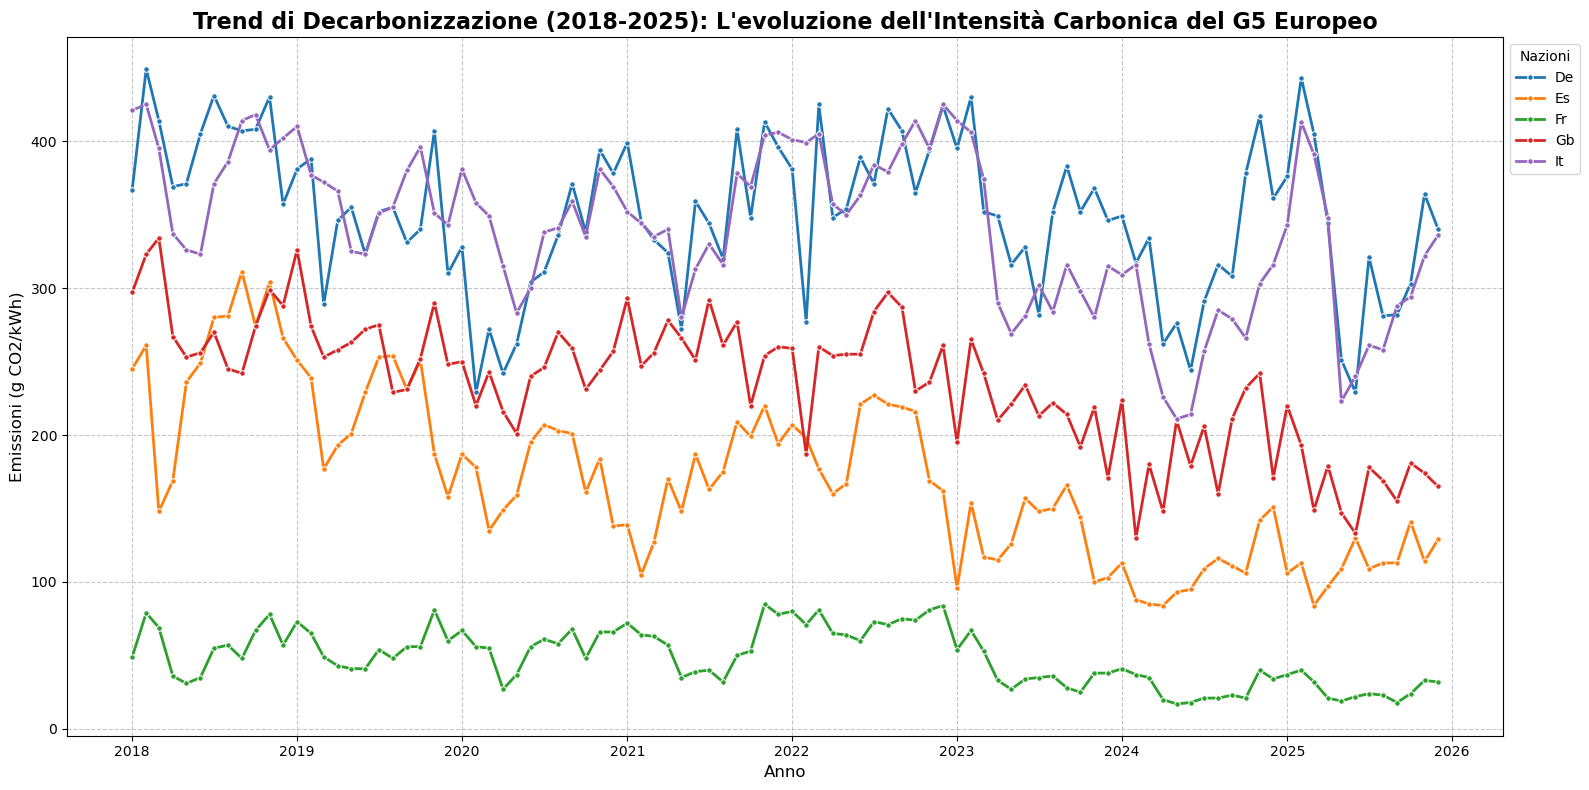

In [3]:
df['date'] = pd.to_datetime(df['month_id'], format='%Y%m')  #convertito month_id in formato data

G5 = ['De','Fr','Gb','It','Es']  #ho scelto di rappresentare le prime 5 potenze europee
df_trend = df[df['country_name'].isin(G5)]

if df_trend.empty:
    print("Errore: il codice ISO non è presente")
else:
    plt.figure(figsize=(16,8))

    sns.lineplot(
        data = df_trend,
        x = 'date',
        y = 'co2_g_kwh',
        hue = 'country_name',
        linewidth = 2,
        marker = 'o',
        markersize = 4,
        palette = 'tab10'
    )       

    plt.title('Trend di Decarbonizzazione (2018-2025): L\'evoluzione dell\'Intensità Carbonica del G5 Europeo', fontsize=16, fontweight='bold')
    plt.xlabel('Anno', fontsize=12)
    plt.ylabel('Emissioni (g CO2/kWh)', fontsize=12)
    
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.legend(bbox_to_anchor=(1, 1), loc='upper left', title="Nazioni")
    plt.tight_layout()

cartella_destinazione = 'figures'
os.makedirs(cartella_destinazione, exist_ok=True)
percorso_file = os.path.join(cartella_destinazione, 'trend_decarbonizzazione_G5.png')
plt.savefig(percorso_file)

### Cosa si vede dal grafico:
- **Francia**: Emissioni stabilmente basse e piatte lungo i 7 anni. Avendo il nucleare come base fissa, non risente minimamente del meteo o della stagionalità.
- **Germania**: Parte altissima nel 2018 ma scende col tempo, probabilmente per la progressiva chiusura delle centrali a carbone. Resta comunque sopra Francia e Spagna.
- **Gran Bretagna e Spagna**: Hanno sbalzi mensili continui. In estate le emissioni scendono (grazie a solare ed eolica) e in inverno risalgono. Dimostrano quanto pesi l'intermittenza delle rinnovabili se non hai un baseload stabile.

## 2. Ranking Europeo: Emissioni Medie e % Rinnovabili (2018-2025)

**Obiettivo:** Confrontare tutti i 26 paesi europei per emissioni medie di CO₂ 
e quota media di rinnovabili sull'intero periodo analizzato.

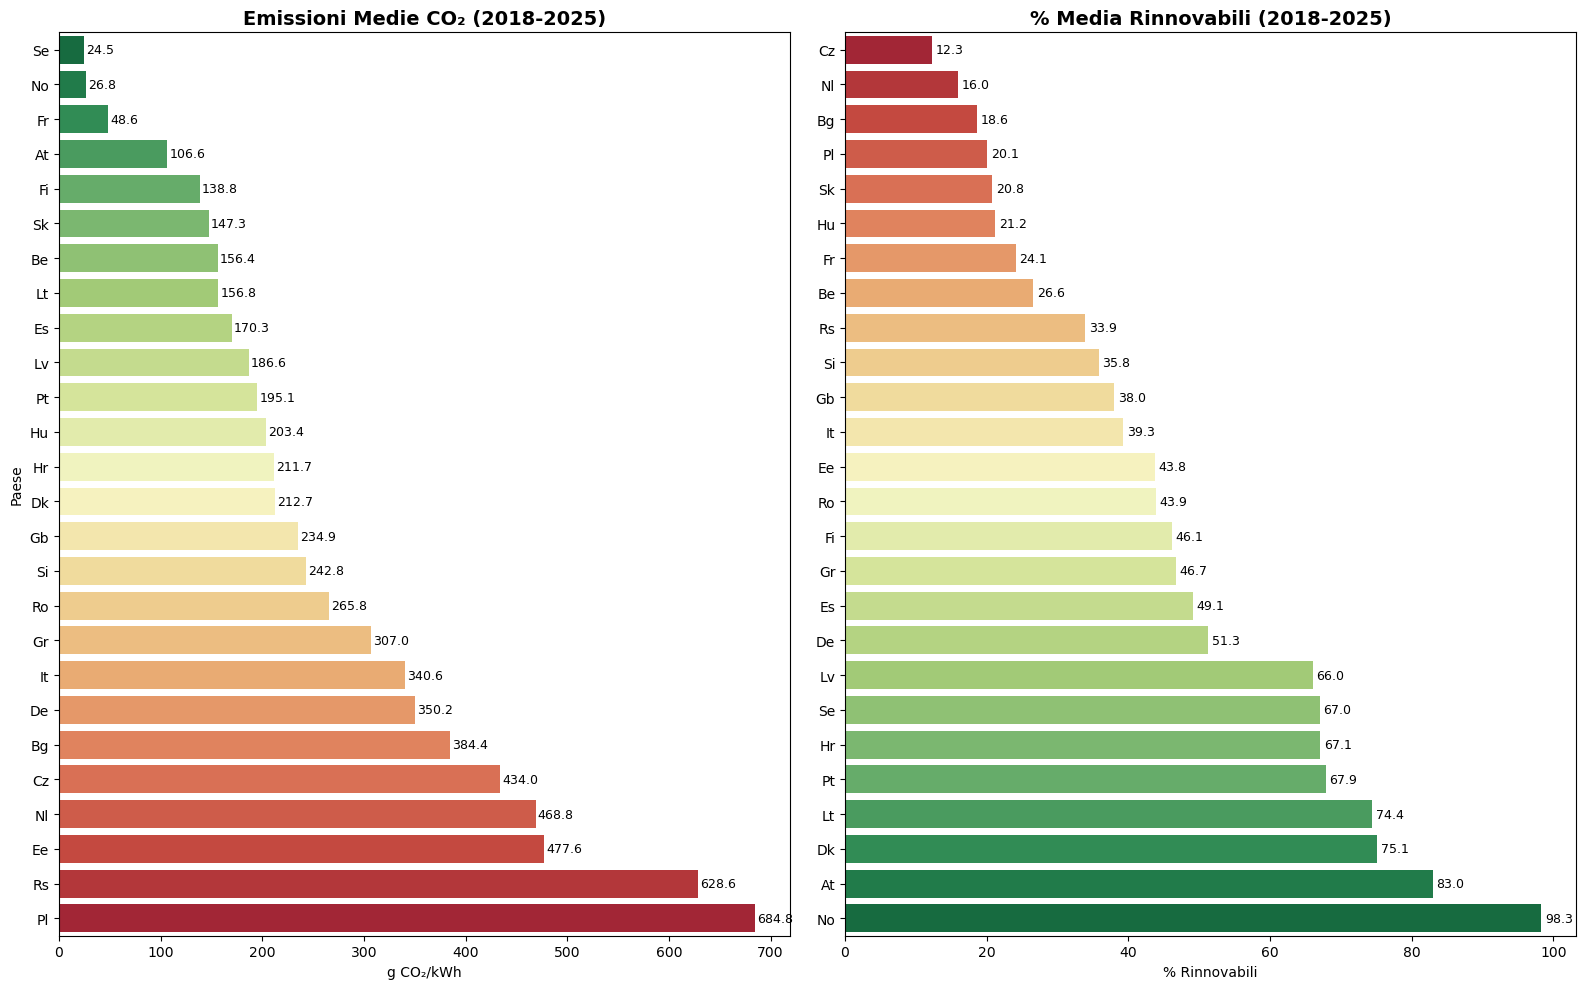

In [4]:
ranking = df.groupby('country_name')[['co2_g_kwh', 'renewable_perc']].mean().round(1)
ranking = ranking.sort_values('co2_g_kwh', ascending=True).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# Grafico 1: Emissioni medie CO₂
sns.barplot(data=ranking, x='co2_g_kwh', y='country_name',
            hue='country_name', palette='RdYlGn_r', 
            legend=False, ax=axes[0])
axes[0].set_title('Emissioni Medie CO₂ (2018-2025)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('g CO₂/kWh')
axes[0].set_ylabel('Paese')
for i, v in enumerate(ranking['co2_g_kwh']):
    axes[0].text(v + 2, i, str(v), va='center', fontsize=9)

# Grafico 2: % Rinnovabili medie
ranking_ren = ranking.sort_values('renewable_perc', ascending=True)
sns.barplot(data=ranking_ren, x='renewable_perc', y='country_name',
            hue='country_name', palette='RdYlGn',
            legend=False, ax=axes[1])
axes[1].set_title('% Media Rinnovabili (2018-2025)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('% Rinnovabili')
axes[1].set_ylabel('')
for i, v in enumerate(ranking_ren['renewable_perc']):
    axes[1].text(v + 0.5, i, str(v), va='center', fontsize=9)

plt.tight_layout()
cartella_destinazione = 'figures'
os.makedirs(cartella_destinazione, exist_ok=True)
percorso_file = os.path.join(cartella_destinazione, 'Emissioni_Medie.png')
plt.savefig(percorso_file)
plt.show()

## 3. Correlazione tra Quota Rinnovabile ed Emissioni di CO₂

**Obiettivo:** Verificare se esiste una relazione statistica tra la percentuale 
di energia prodotta da fonti rinnovabili e l'intensità carbonica della 
produzione elettrica.


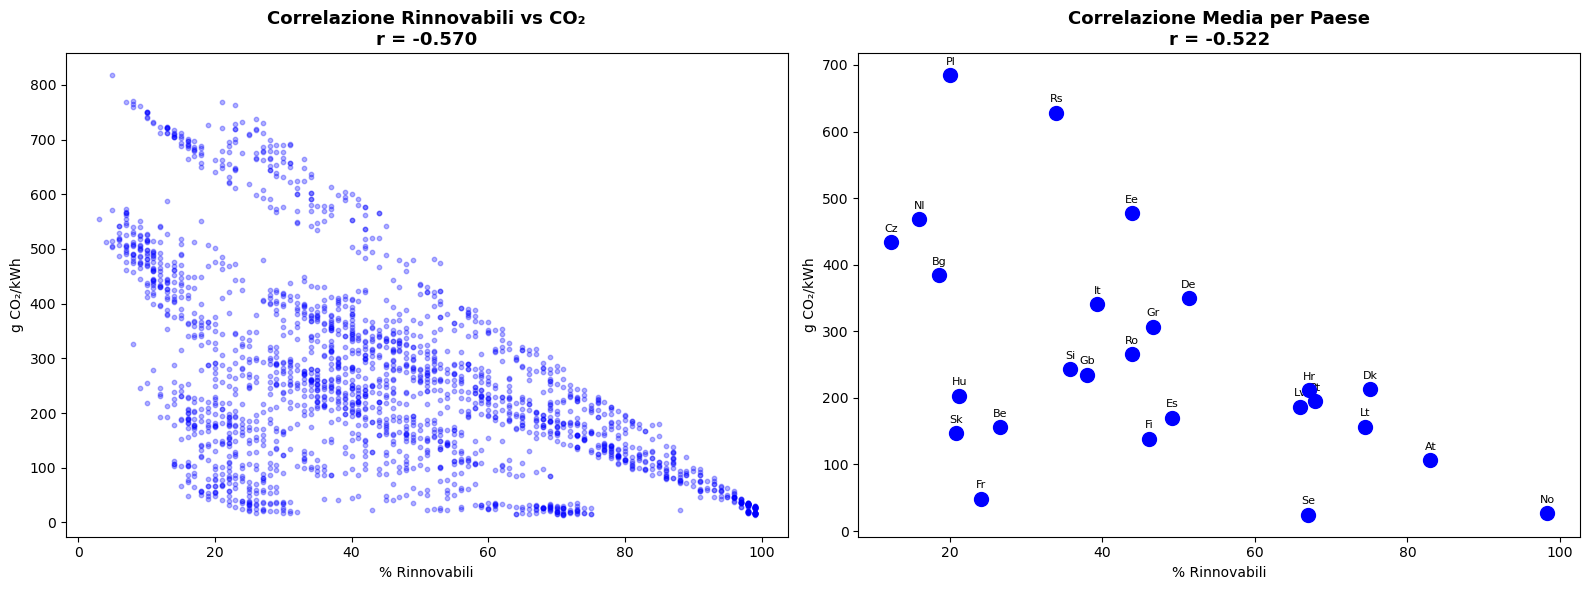

In [5]:
media_paesi = df.groupby('country_name')[['renewable_perc', 'co2_g_kwh']].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

r = df['renewable_perc'].corr(df['co2_g_kwh'])
r2 = media_paesi['renewable_perc'].corr(media_paesi['co2_g_kwh'])

# Grafico 1: Scatterplot tutti i dati
axes[0].scatter(df['renewable_perc'], df['co2_g_kwh'],
                alpha=0.3, color='blue', s=10)
axes[0].set_title(f'Correlazione Rinnovabili vs CO₂\nr = {r:.3f}',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('% Rinnovabili')
axes[0].set_ylabel('g CO₂/kWh')

# Grafico 2: Media per paese con etichette
media_paesi = df.groupby('country_name')[['renewable_perc', 'co2_g_kwh']].mean()
axes[1].scatter(media_paesi['renewable_perc'], media_paesi['co2_g_kwh'],
                color='blue', s=100, zorder=5)
for paese, row in media_paesi.iterrows():
    axes[1].annotate(paese, 
                     (row['renewable_perc'], row['co2_g_kwh']),
                     fontsize=8, 
                     ha='center', 
                     va='bottom',
                     xytext=(0, 6),
                     textcoords='offset points')
axes[1].set_title(f'Correlazione Media per Paese\nr = {r2:.3f}',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('% Rinnovabili')
axes[1].set_ylabel('g CO₂/kWh')

plt.tight_layout()
cartella_destinazione = 'figures'
os.makedirs(cartella_destinazione, exist_ok=True)
percorso_file = os.path.join(cartella_destinazione, 'Correlazioni_Ren_Co2.png')
plt.savefig(percorso_file)
plt.show()

### Risultati della correlazione
L'indice a -0.570 conferma la logica: più rinnovabili inserisci nel mix, meno CO2 emetti. La correlazione non è un -1.0 perfetto perché ci sono eccezioni strutturali, prima tra tutte la Francia, che ha pochissima CO2 pur usando poche rinnovabili (grazie all'atomo).

Sullo scatterplot delle medie per nazione (-0.522) i casi limite sono chiarissimi: Norvegia e Svezia in basso a destra (pulitissime), Polonia e Serbia opposte in alto a sinistra (inchiodate ai fossili).

## 4. HeatMap: Intensità Carbonica Europea (2025)

**Obiettivo:** Visualizzare simultaneamente l'intensità carbonica di tutti 
i paesi europei mese per mese durante il 2025, per identificare pattern 
stagionali e differenze strutturali tra nazioni.

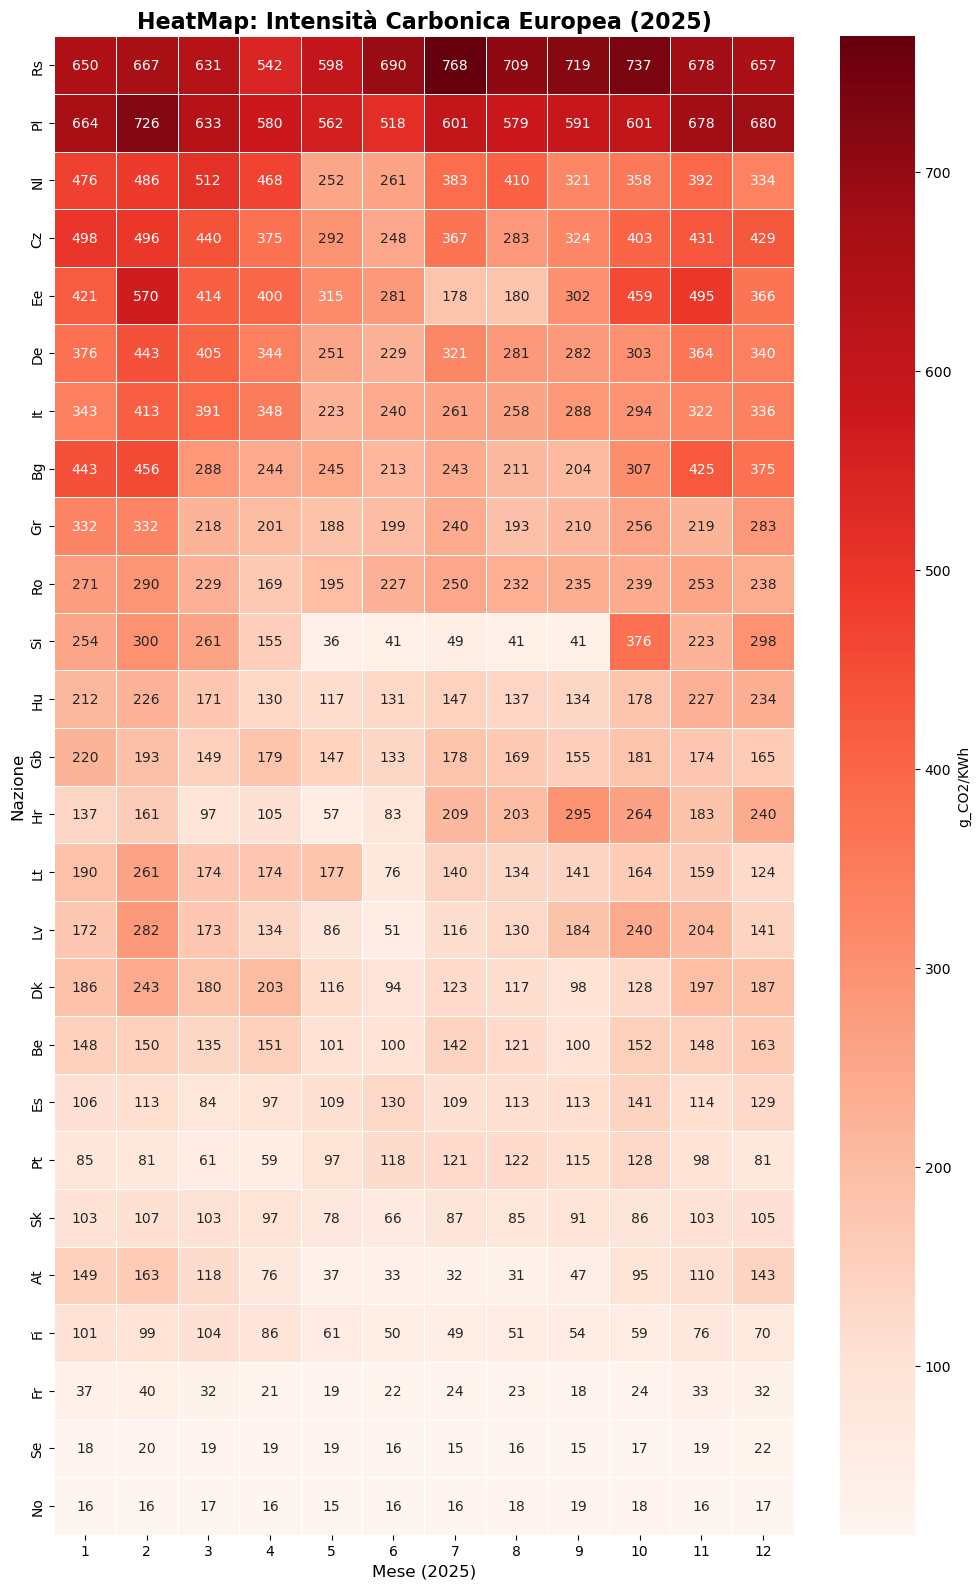

In [6]:
df_2025 = df[df['date'].dt.year == 2025].copy()

pivot_2025 = df_2025.pivot_table(index='country_name', columns = df['date'].dt.month, values = 'co2_g_kwh')
pivot_2025['media'] = pivot_2025.mean(axis=1)
pivot_2025 = pivot_2025.sort_values(by='media', ascending=False).drop(columns=['media'])


plt.figure(figsize=(10,16))
sns.heatmap(pivot_2025, cmap='Reds', annot=True, fmt=".0f", linewidths=.5, cbar_kws = {'label': 'g_CO2/KWh'})

plt.title('HeatMap: Intensità Carbonica Europea (2025)', fontsize=16, fontweight='bold')
plt.xlabel('Mese (2025)', fontsize=12)
plt.ylabel('Nazione', fontsize=12)
plt.tight_layout()


cartella_destinazione = 'figures'
os.makedirs(cartella_destinazione, exist_ok=True)
percorso_file = os.path.join(cartella_destinazione, 'heatmap_2025.png')
plt.savefig(percorso_file)

plt.show()

## 5. Analisi Statistica: Le determinanti delle emissioni in Slovenia

**Obiettivo:** 

Prima di analizzare l'andamento storico, utilizziamo una matrice di correlazione (Indice di Pearson) per esporre le regole strutturali che governano la rete elettrica slovena.

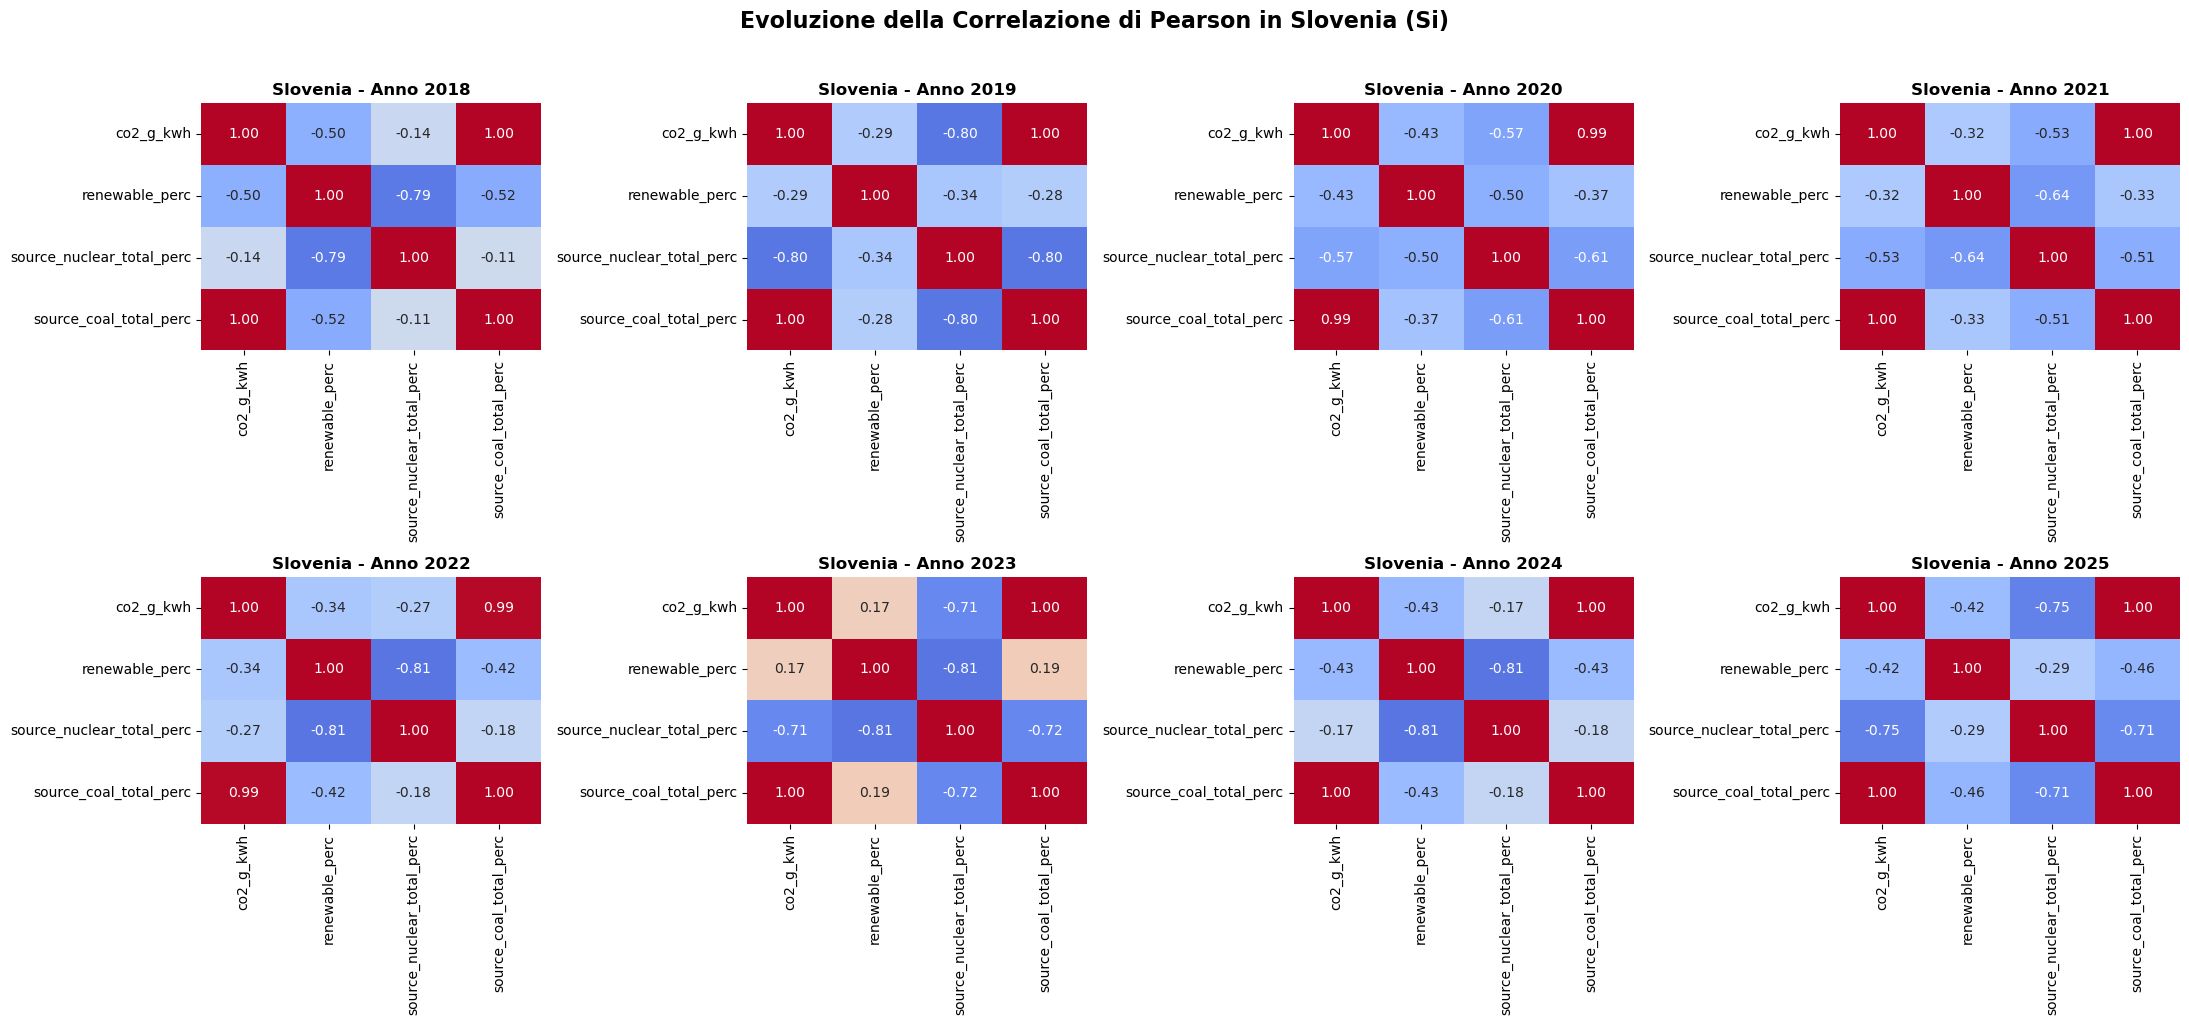

In [7]:
import math

df['year'] = df['month_id'] // 100  

# Filtra per la Slovenia ('Si')
nazione = 'Si'
df_slovenia = df[df['country_name'] == nazione]

# Definisci le colonne per la matrice
colonne_analisi = ['co2_g_kwh', 'renewable_perc', 'source_nuclear_total_perc', 'source_coal_total_perc']
anni = sorted(df_slovenia['year'].unique())

# Configura la griglia di heatmap
cols = 4
righe = math.ceil(len(anni) / cols)
fig, axes = plt.subplots(righe, cols, figsize=(22, 5 * righe))
axes = axes.flatten()

# Loop attraverso gli anni per calcolare e plottare ogni matrice
for i, anno in enumerate(anni):
    df_anno = df_slovenia[df_slovenia['year'] == anno][colonne_analisi].dropna()
    
    if len(df_anno) > 1:
        matrice_corr = df_anno.corr(method='pearson')
        sns.heatmap(
            matrice_corr, 
            annot=True, 
            cmap='coolwarm', 
            fmt=".2f", 
            vmin=-1, 
            vmax=1, 
            cbar=False,  # Togliamo le barre singole per pulizia visiva
            ax=axes[i]
        )
        axes[i].set_title(f'Slovenia - Anno {anno}', fontsize=12, fontweight='bold')
    else:
        axes[i].text(0.5, 0.5, f'Dati insufficienti\nper il {anno}', ha='center', va='center')

# Rimuove i riquadri vuoti se l'ultimo ciclo non riempie la griglia
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(f'Evoluzione della Correlazione di Pearson in Slovenia ({nazione})', fontsize=16, y=1.02, fontweight='bold')
plt.tight_layout()

cartella_destinazione = 'figures'
os.makedirs(cartella_destinazione, exist_ok=True)
percorso_file = os.path.join(cartella_destinazione, 'Correlazione_Pearson_SI.png')
plt.savefig(percorso_file)
plt.show()

### Cosa dice la matrice sulla Slovenia:
L'indice di Pearson evidenzia due legami strutturali netti:
1. **Carbone e CO2 (0.84)**: Quando sale la quota di carbone, le emissioni schizzano istantaneamente. È la fonte che pesa di più sul loro bilancio energetico.
2. **Nucleare e Carbone (-0.79)**: C'è un rimpiazzo quasi matematico. Se la quota di nucleare scende, la Slovenia copre il buco accendendo il carbone, non con le rinnovabili.

## 6. La verifica empirica: Il crollo del Baseload (Ottobre 2019)

Grafico a doppio asse per verificare cosa succede sul campo quando si ferma la fonte principale

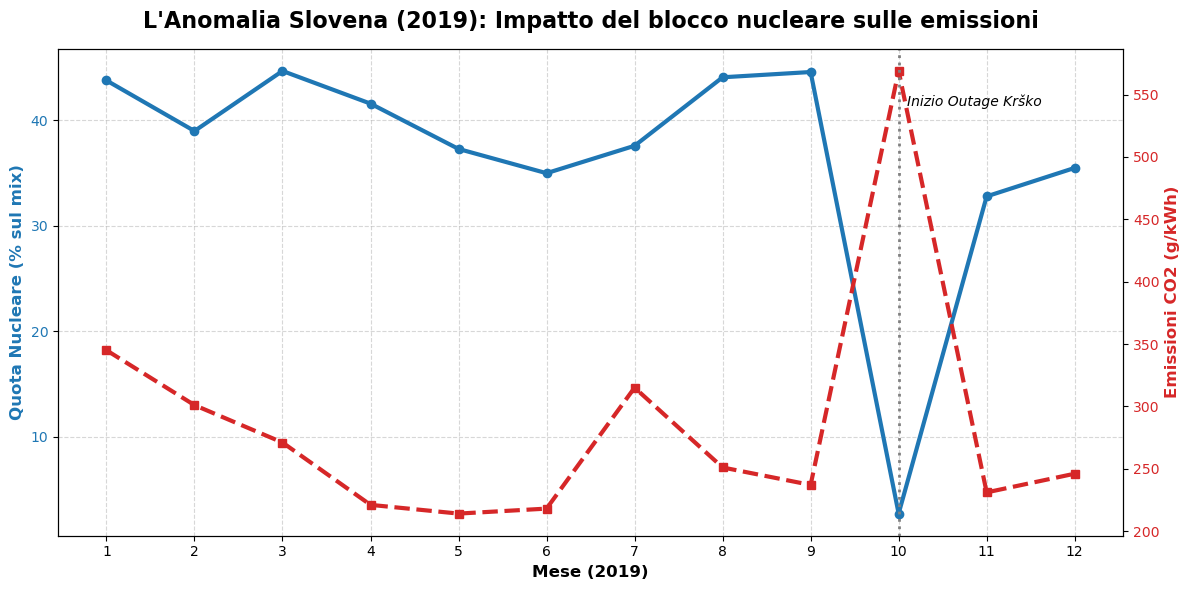

In [8]:
df['year'] = df['month_id'] // 100
df['month'] = df['month_id'] % 100

# Filtra i dati: Solo Slovenia ('Si'), solo anno 2019
df_si_2019 = df[(df['country_name'] == 'Si') & (df['year'] == 2019)].copy()
df_si_2019 = df_si_2019.sort_values('month') # Ci assicuriamo che i mesi siano in ordine

# Inizializza il grafico a doppio asse Y
fig, ax1 = plt.subplots(figsize=(12, 6))

# Asse Sinistro: Nucleare
colore_nucleare = '#1f77b4' # Blu
ax1.set_xlabel('Mese (2019)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Quota Nucleare (% sul mix)', color=colore_nucleare, fontsize=12, fontweight='bold')
ax1.plot(df_si_2019['month'], df_si_2019['source_nuclear_total_perc'], 
         color=colore_nucleare, marker='o', linewidth=3, label='Nucleare')
ax1.tick_params(axis='y', labelcolor=colore_nucleare)

# Imposta le etichette dell'asse X da 1 a 12
ax1.set_xticks(range(1, 13))
ax1.grid(True, linestyle='--', alpha=0.5)

# Asse Destro: Co2
ax2 = ax1.twinx() # Crea un asse gemello che condivide lo stesso asse X
colore_co2 = '#d62728' 
ax2.set_ylabel('Emissioni CO2 (g/kWh)', color=colore_co2, fontsize=12, fontweight='bold')
ax2.plot(df_si_2019['month'], df_si_2019['co2_g_kwh'], 
         color=colore_co2, marker='s', linestyle='--', linewidth=3, label='CO2')
ax2.tick_params(axis='y', labelcolor=colore_co2)

plt.title("L'Anomalia Slovena (2019): Impatto del blocco nucleare sulle emissioni", 
          fontsize=16, fontweight='bold', pad=15)

# Aggiungiamo una linea verticale per evidenziare il mese del crollo (ottobre)
plt.axvline(x=10, color='grey', linestyle=':', linewidth=2)
plt.text(10.1, df_si_2019['co2_g_kwh'].max() * 0.95, 'Inizio Outage Krško', fontsize=10, style='italic')

fig.tight_layout()
cartella_destinazione = 'figures'
os.makedirs(cartella_destinazione, exist_ok=True)
percorso_file = os.path.join(cartella_destinazione, 'Anomalia_Slovenia.png')
plt.savefig(percorso_file)
plt.show()

### Il caso limite di Ottobre 2019
La linea verticale segna il mese in cui la centrale nucleare di Krško è stata fermata per manutenzione programmata. Come si vede, la linea blu (nucleare) crolla a zero e la linea rossa (CO2) subisce un'impennata immediata. Questo succede perché il deficit energetico è stato coperto interamente dal carbone, confermando la dipendenza della rete slovena dalle fonti fossili quando manca il carico di base.

## 7. Network Analysis: Similarità delle Strategie Energetiche Europee

Per questa analisi ho usato NetworkX per costruire un grafo in cui i nodi rappresentano i paesi europei e gli archi indicano una forte similarità nel mix energetico.

La similarità è calcolata come correlazione di Pearson tra i vettori delle fonti energetiche medie del 2025 per ogni coppia di paesi. Ho scelto una soglia del 90% per tracciare un arco — solo le coppie con correlazione ≥ 0.90 vengono collegate, in modo da evidenziare solo le somiglianze strutturali più forti.

Il colore di ogni nodo rappresenta l'intensità carbonica media del paese: 
verde per emissioni basse, rosso per emissioni alte. Il layout a molla posiziona i nodi in base alle connessioni — i paesi più simili tendono a trovarsi vicini nel grafico.

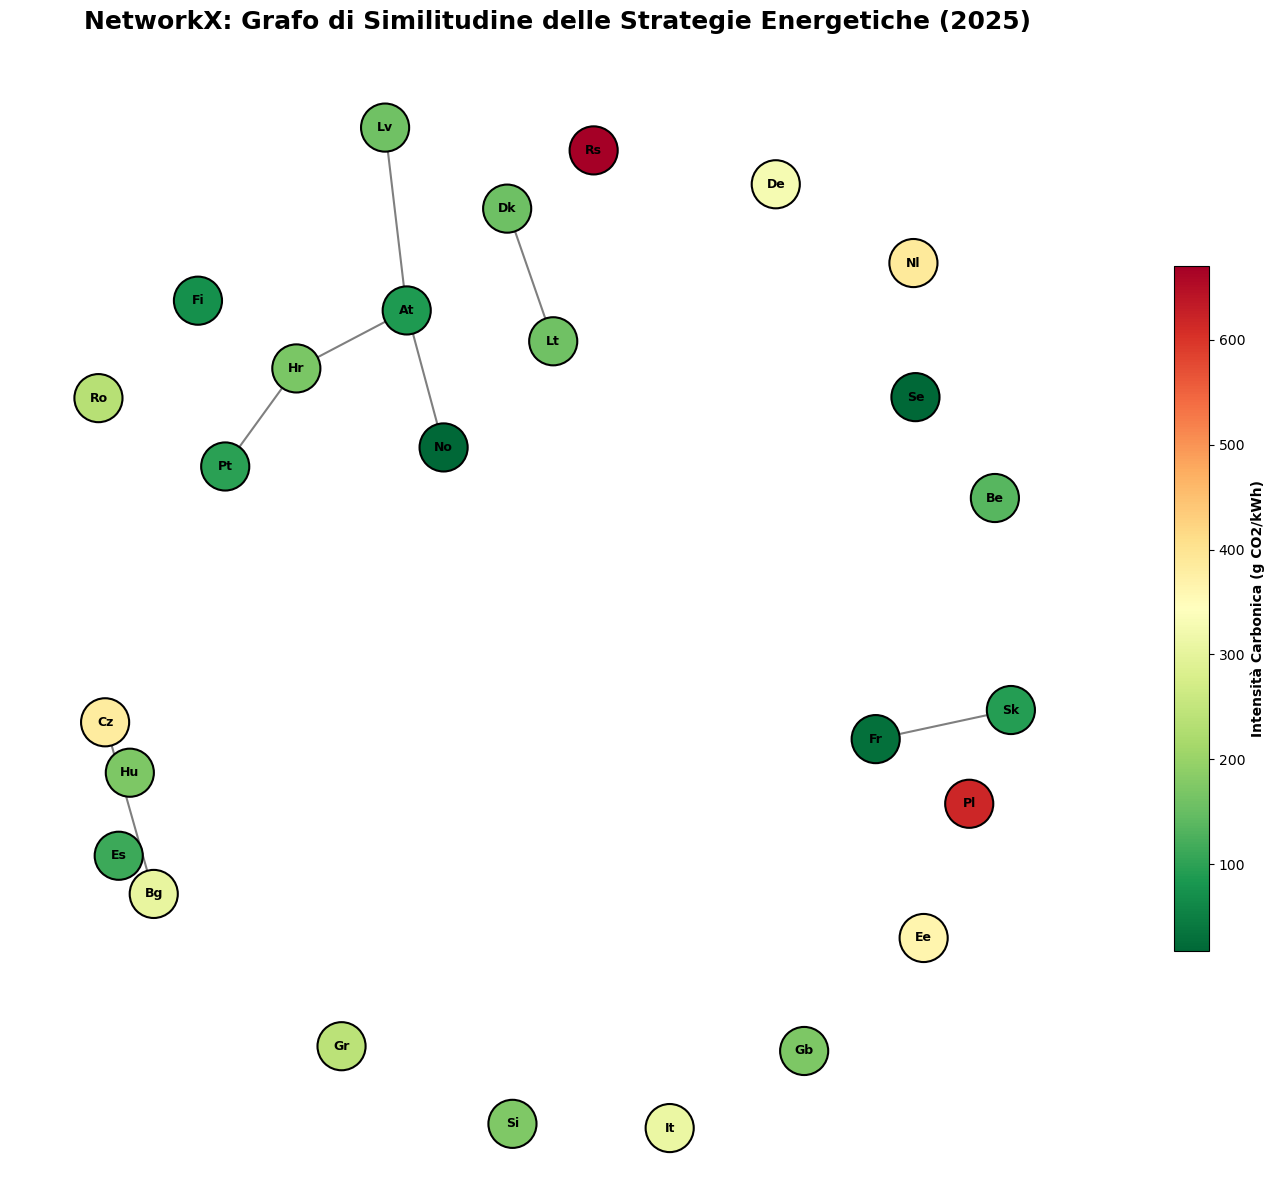

In [9]:
df_2025 = df[df['date'].dt.year == 2025].copy()

fonti = ['source_coal_total_perc', 'source_gas_total_perc', 'source_nuclear_total_perc', 
         'source_hydro_total_perc', 'source_solar_total_perc', 'source_wind_total_perc']

mix_medio = df_2025.groupby('country_name')[fonti].mean()
co2_media = df_2025.groupby('country_name')['co2_g_kwh'].mean()

# Calcoliamo la matrice di correlazione tra nazioni
correlazione = mix_medio.T.corr()

# Inizializziamo il grafo NetworkX
G = nx.Graph()

# Aggiungiamo i nodi assegnando la CO2 come attributo
for nazione in correlazione.columns:
    G.add_node(nazione, co2=co2_media[nazione])

# Aggiungiamo gli archi SOLO se la similitudine è molto alta (>= 0.90)
soglia_similitudine = 0.90
for i in range(len(correlazione.columns)):
    for j in range(i+1, len(correlazione.columns)):
        nazione1 = correlazione.columns[i]
        nazione2 = correlazione.columns[j]
        peso = correlazione.iloc[i, j]
        if peso >= soglia_similitudine:
            G.add_edge(nazione1, nazione2, weight=peso)

plt.figure(figsize=(14, 12))

# Il parametro 'k' più alto (es. 1) fa "esplodere" il grafo spingendo i nodi più lontani. 
# 'iterations' dà al layout più tempo per stabilizzarsi.
pos = nx.spring_layout(G, seed=42, k=1, iterations=100) 

colori_nodi = [G.nodes[n]['co2'] for n in G.nodes()]

# Disegniamo gli archi un po' più leggeri
nx.draw_networkx_edges(G, pos, alpha=0.5, width=1.5, edge_color='black')

# Disegniamo i nodi
nodi_disegnati = nx.draw_networkx_nodes(G, pos, node_size=1200, node_color=colori_nodi, 
                                        cmap='RdYlGn_r', edgecolors='black', linewidths=1.5)


nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold', font_color='black')

cbar = plt.colorbar(nodi_disegnati, shrink=0.6)
cbar.set_label('Intensità Carbonica (g CO2/kWh)', fontweight='bold')

plt.title('NetworkX: Grafo di Similitudine delle Strategie Energetiche (2025)', fontsize=18, fontweight='bold')
plt.axis('off')
plt.tight_layout()

cartella_destinazione = 'figures'
os.makedirs(cartella_destinazione, exist_ok=True)
percorso_file = os.path.join(cartella_destinazione, 'NetworkX_Similarità_2025.png')
plt.savefig(percorso_file)

plt.show()

### I Cluster del 2025
Dal grafo emergono pochi gruppi simili:
- **Cluster Rinnovabili/Idro**: Austria, Croazia, Lettonia e Lituania sono vicine e verdi (emissioni basse).
- **Isolati**: La maggior parte dei paesi non ha un "gemello" sopra il 90% di somiglianza. Polonia e Serbia restano i nodi più distanti e nettamente più rossi.

## 8. Evoluzione del Grafo di Similarità nel Tempo (2018, 2021, 2025)

**Obiettivo:** Analizzare se i cluster energetici europei sono cambiati nel tempo.
L'ipotesi è che la transizione energetica abbia avvicinato alcuni paesi e 
allontanato altri, modificando la struttura del grafo tra il 2018 e il 2025.

**Metodologia:** Lo stesso grafo di similarità viene costruito separatamente 
per tre anni chiave: 2018 (baseline), 2021 (post-pandemia), 2025 (stato attuale).

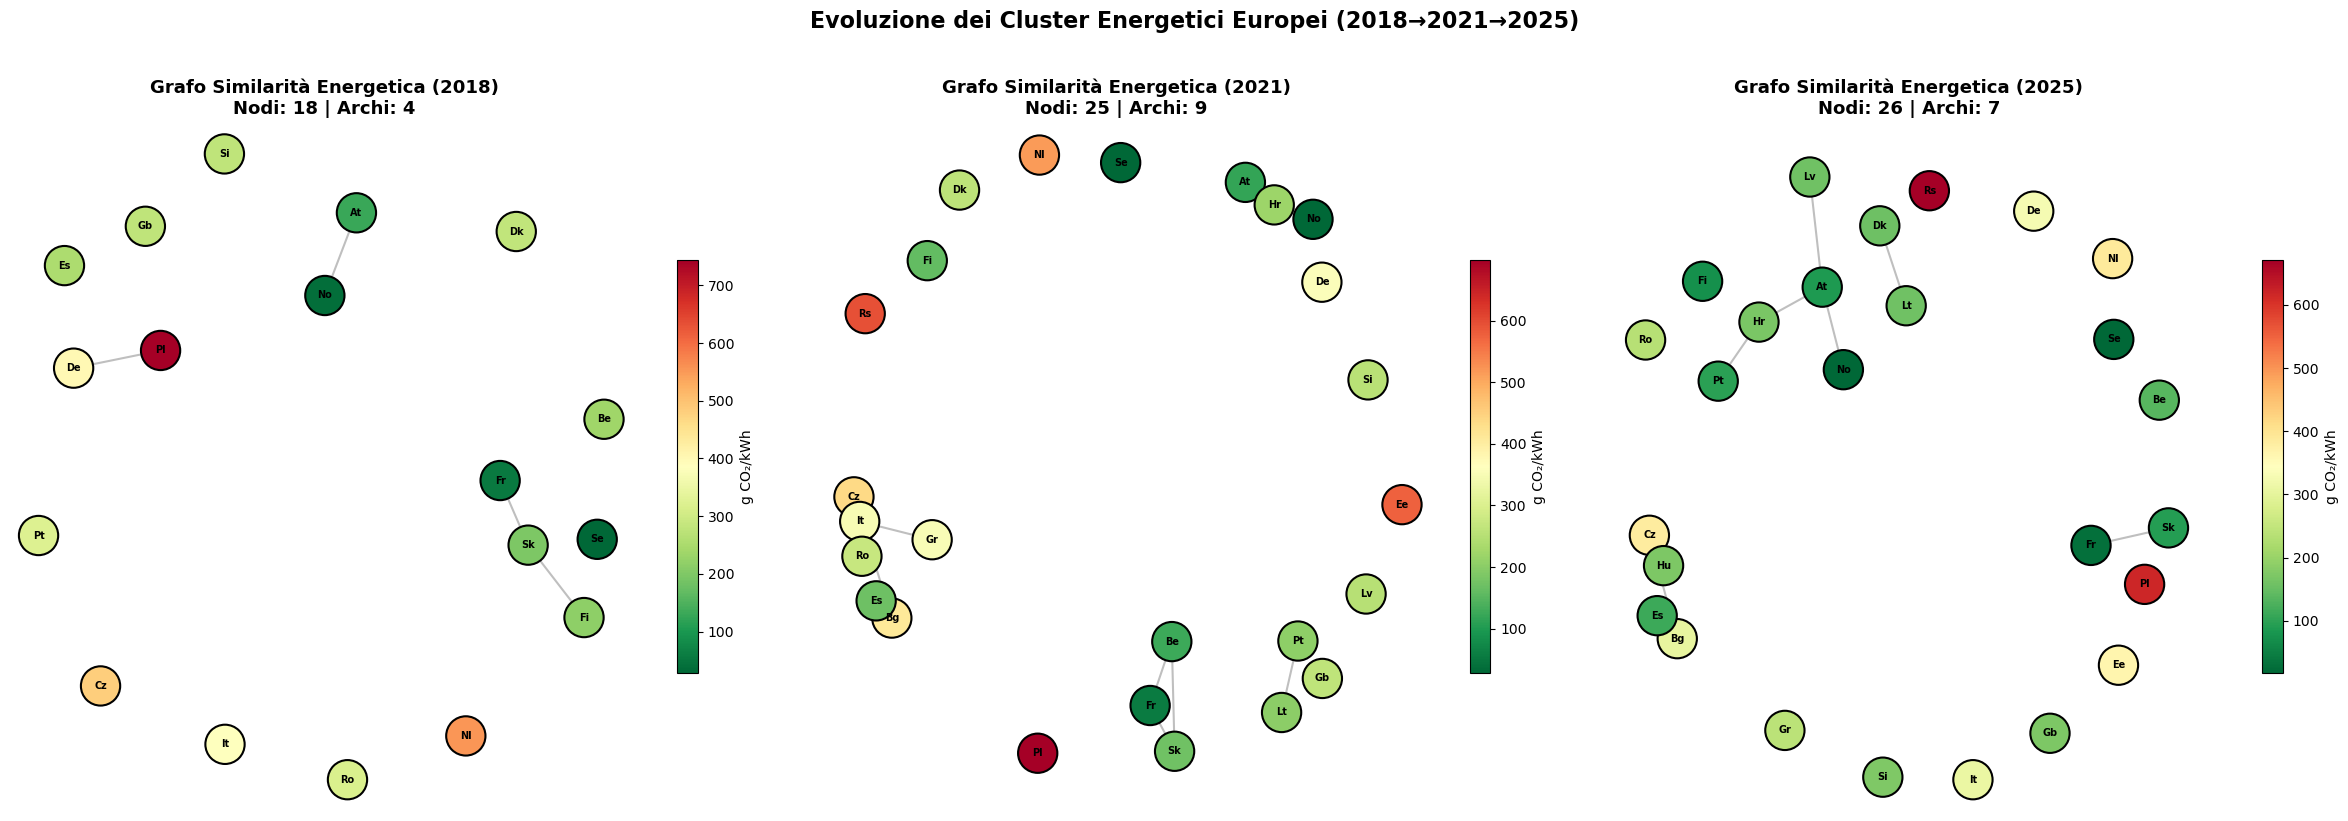

In [10]:
fonti = ['source_coal_total_perc', 'source_gas_total_perc', 'source_nuclear_total_perc', 
         'source_hydro_total_perc', 'source_solar_total_perc', 'source_wind_total_perc']
anni_chiave = [2018, 2021, 2025]
soglia = 0.90

fig, axes = plt.subplots(1, 3, figsize=(24, 8))

for idx, anno in enumerate(anni_chiave):
    df_anno = df[df['year'] == anno].copy()
    
    mix_medio = df_anno.groupby('country_name')[fonti].mean()
    co2_media = df_anno.groupby('country_name')['co2_g_kwh'].mean()
    
    # Rimuovi paesi con dati mancanti
    mix_medio = mix_medio.dropna()
    paesi_validi = mix_medio.index
    co2_media = co2_media[paesi_validi]
    
    correlazione = mix_medio.T.corr()
    
    G = nx.Graph()
    for nazione in correlazione.columns:
        G.add_node(nazione, co2=co2_media[nazione])
    
    for i in range(len(correlazione.columns)):
        for j in range(i+1, len(correlazione.columns)):
            n1 = correlazione.columns[i]
            n2 = correlazione.columns[j]
            peso = correlazione.iloc[i, j]
            if peso >= soglia:
                G.add_edge(n1, n2, weight=peso)
    
    pos = nx.spring_layout(G, seed=42, k=1, iterations=100)
    colori = [G.nodes[n]['co2'] for n in G.nodes()]
    
    nx.draw_networkx_edges(G, pos, alpha=0.5, width=1.5, 
                           edge_color='gray', ax=axes[idx])
    nodi = nx.draw_networkx_nodes(G, pos, node_size=800,
                                   node_color=colori, cmap='RdYlGn_r',
                                   edgecolors='black', linewidths=1.5,
                                   ax=axes[idx])
    nx.draw_networkx_labels(G, pos, font_size=7, font_weight='bold',
                            ax=axes[idx])
    
    axes[idx].set_title(f'Grafo Similarità Energetica ({anno})\n'
                        f'Nodi: {G.number_of_nodes()} | Archi: {G.number_of_edges()}',
                        fontsize=13, fontweight='bold')
    axes[idx].axis('off')
    plt.colorbar(nodi, ax=axes[idx], shrink=0.6, 
                 label='g CO₂/kWh')

plt.suptitle('Evoluzione dei Cluster Energetici Europei (2018→2021→2025)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/Network_Similarity_Evo.png', dpi=150, bbox_inches='tight')
plt.show()


### Interpretazione dell'Evoluzione

Il numero di archi cambia nei tre anni analizzati: 4 nel 2018, 9 nel 2021, 7 nel 2025.

Nel 2018 il grafo è molto sparso — pochi paesi hanno mix energetici sufficientemente simili da superare la soglia del 90%. Questo riflette una situazione di partenza in cui ogni paese aveva ancora una struttura energetica abbastanza propria.

Nel 2021 le connessioni aumentano. Una possibile spiegazione è che negli anni precedenti molti paesi avevano iniziato ad aumentare la quota di rinnovabili in modo simile, convergendo verso mix più omogenei.

Nel 2025 gli archi scendono leggermente a 7. Questo potrebbe indicare che i percorsi di transizione si stanno differenziando — alcuni paesi puntano prevalentemente sul solare, altri sull'eolico, altri mantengono una base nucleare — riducendo la somiglianza complessiva tra i mix.

Polonia e Serbia risultano isolate in tutti e tre gli anni, con i nodi sempre tra i più rossi. La loro traiettoria sembra distaccarsi dal resto d'Europa per tutto il periodo analizzato.